In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [49]:
ethiopia = pd.read_csv('data/ethiopia_clean.csv')
kenya = pd.read_csv('data/kenya_clean.csv')
nigeria = pd.read_csv('data/nigeria_clean.csv')
sudan = pd.read_csv('data/sudan_clean.csv')
tanzania = pd.read_csv('data/tanzania_clean.csv')

In [50]:
ethiopia['Country'] = 'Ethiopia'
kenya['Country'] = 'Kenya'
nigeria['Country'] = 'Nigeria'
sudan['Country'] = 'Sudan'
tanzania['Country'] = 'Tanzania'

In [51]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index = True)
df.head(8000)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.35,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,2025,235,25.24,28.37,22.83,5.54,1.16,74.57,4.32,5.80,101.03,14.74,Kenya,2025-08-23,8
7996,2025,236,25.28,27.45,23.43,4.02,0.49,76.52,4.71,6.06,101.09,15.23,Kenya,2025-08-24,8
7997,2025,237,25.65,28.27,23.74,4.53,0.11,71.09,4.58,5.78,101.20,14.43,Kenya,2025-08-25,8
7998,2025,238,25.50,28.59,23.28,5.31,0.14,74.67,4.68,5.66,101.32,14.94,Kenya,2025-08-26,8


In [52]:
df['Date']=pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format = '%Y%j')

In [53]:
monthly_temp = (
    df.groupby(['Country', 'Date'])['T2M'].mean().reset_index()
)

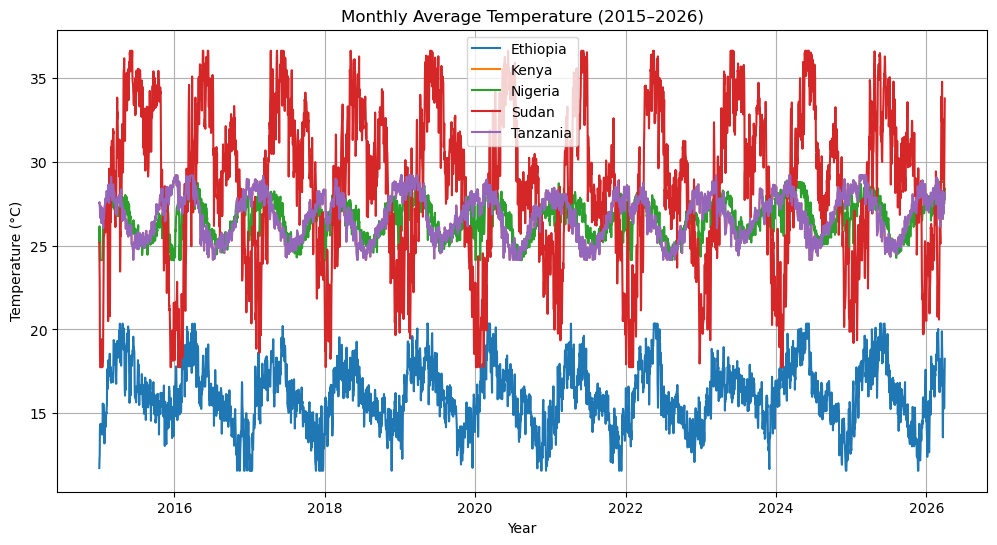

In [54]:
plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Date"], subset["T2M"], label=country)

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()

In [55]:
summary_stats = (
    df.groupby("Country")["T2M"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

summary_stats

,Country,mean,median,std
0,Ethiopia,16.071010,16.04,1.871711
1,Kenya,26.803544,26.99,1.314036
2,Nigeria,26.661339,26.82,1.099749
3,Sudan,28.764489,29.16,4.646585
4,Tanzania,26.803544,26.99,1.314036


In [56]:
df[['Country', 'PRECTOTCORR']].head()

,Country,PRECTOTCORR
0,Ethiopia,0.0
1,Ethiopia,0.0
2,Ethiopia,0.0
3,Ethiopia,0.0
4,Ethiopia,0.0


<Figure size 1000x600 with 0 Axes>

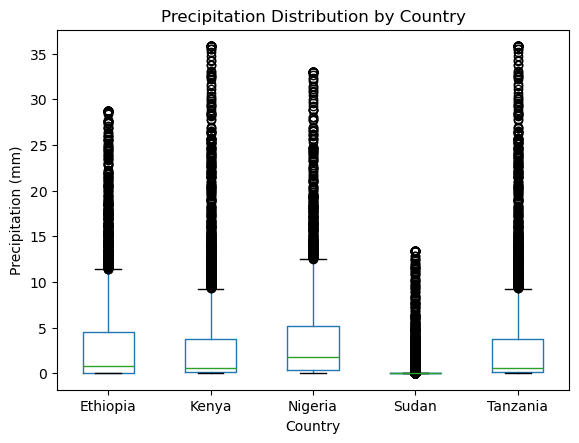

In [57]:
plt.figure(figsize=(10,6))

df.boxplot(column='PRECTOTCORR', by='Country')

plt.title("Precipitation Distribution by Country")
plt.suptitle("") 
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.grid()

plt.show()

In [58]:
precip_stats = (
    df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()
)

In [59]:
precip_stats = precip_stats.sort_values(by="std", ascending=False)
precip_stats

,Country,mean,median,std
1,Kenya,3.535145,0.64,6.511813
4,Tanzania,3.535145,0.64,6.511813
2,Nigeria,4.045154,1.84,5.874570
0,Ethiopia,3.543652,0.82,5.775581
3,Sudan,0.534246,0.00,1.949844


In [60]:
df['Year'] = df['Date'].dt.year

In [61]:
df['Extreme Heat'] = df['T2M_MAX'] > 35

In [62]:
heat_counts = (
    df.groupby(['Country', 'Year'])['Extreme Heat'].sum().reset_index()
)

In [63]:
heat_summary = (
    heat_counts.groupby('Country')['Extreme Heat'].mean().reset_index()
)

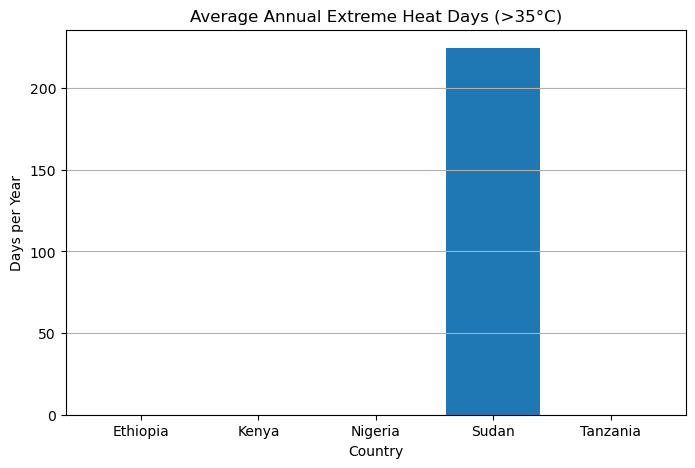

In [64]:
plt.figure(figsize=(8,5))

plt.bar(heat_summary['Country'], heat_summary['Extreme Heat'])

plt.title("Average Annual Extreme Heat Days (>35°C)")
plt.xlabel("Country")
plt.ylabel("Days per Year")
plt.grid(axis='y')

plt.show()

In [65]:
df['Dry Day'] = df['PRECTOTCORR'] < 1

In [66]:
def max_consecutive_dry_days(group):
    max_streak = 0
    current_streak = 0

    for is_dry in group['Dry Day']:
        if is_dry:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0

    return max_streak

In [67]:
dry_streaks = (
    df.sort_values('Date')
    .groupby(['Country', 'Year'])
    .apply(max_consecutive_dry_days)
    .reset_index(name='Max_Dry_Streak')
)


/var/folders/xs/zq2078pd61l68rrzh14wczj00000gp/T/ipykernel_22202/1694292837.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_consecutive_dry_days)


In [68]:
dry_summary = (
    dry_streaks.groupby('Country')['Max_Dry_Streak'].mean().reset_index()
)

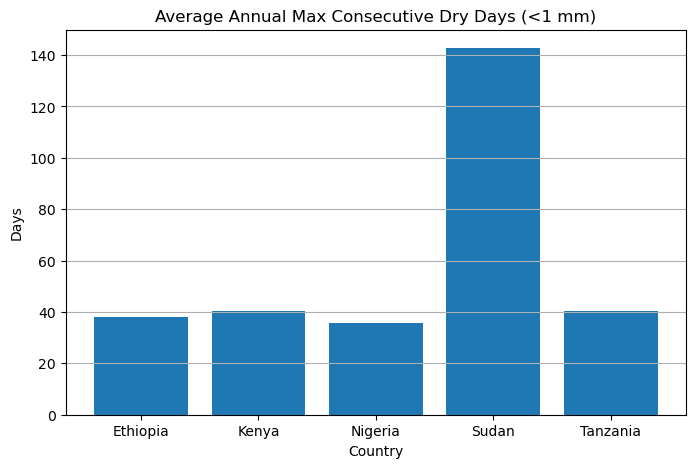

In [69]:
plt.figure(figsize=(8,5))

plt.bar(dry_summary['Country'], dry_summary['Max_Dry_Streak'])

plt.title("Average Annual Max Consecutive Dry Days (<1 mm)")
plt.xlabel("Country")
plt.ylabel("Days")
plt.grid(axis='y')

plt.show()

In [74]:
# Temperature variability
temp_var = df.groupby("Country")["T2M"].std().reset_index(name="Temp_Std")

# Precipitation variability
precip_var = df.groupby("Country")["PRECTOTCORR"].std().reset_index(name="Precip_Std")

# Extreme heat
heat_summary = heat_summary.rename(columns={"Extreme Heat": "Heat_Days"})

# Dry streaks
dry_summary = dry_summary.rename(columns={"Max_Dry_Streak": "Dry_Streak"})

# Merge everything
vulnerability = temp_var.merge(precip_var, on="Country") \
                        .merge(heat_summary, on="Country") \
                        .merge(dry_summary, on="Country")

vulnerability

,Country,Temp_Std,Precip_Std,Heat_Days,Dry_Streak
0,Ethiopia,1.871711,5.775581,0.0,37.916667
1,Kenya,1.314036,6.511813,0.0,40.250000
2,Nigeria,1.099749,5.874570,0.0,35.833333
3,Sudan,4.646585,1.949844,224.5,142.750000
4,Tanzania,1.314036,6.511813,0.0,40.250000


In [75]:
scaler = MinMaxScaler()
vulnerability[['Temp_Std', 'Precip_Std', 'Heat_Days', 'Dry_Streak']]= scaler.fit_transform(
    vulnerability[['Temp_Std', 'Precip_Std', 'Heat_Days', 'Dry_Streak']]
)

In [79]:
vulnerability['Vulnerability_Score'] = (
    vulnerability['Temp_Std']+
    vulnerability['Precip_Std']+
    vulnerability['Heat_Days'] +
    vulnerability['Dry_Streak']
)

vulnerability = vulnerability.sort_values(by = 'Vulnerability_Score', ascending = False)

vulnerability

,Country,Temp_Std,Precip_Std,Heat_Days,Dry_Streak,Vulnerability_Score
3,Sudan,1.000000,0.000000,1.0,1.000000,3.000000
1,Kenya,0.060416,1.000000,0.0,0.041309,1.101726
4,Tanzania,0.060416,1.000000,0.0,0.041309,1.101726
0,Ethiopia,0.217648,0.838615,0.0,0.019486,1.075749
2,Nigeria,0.000000,0.860314,0.0,0.000000,0.860314


In [78]:
vulnerability[['Country', 'Vulnerability_Score']]

,Country,Vulnerability_Score
3,Sudan,3.000000
1,Kenya,1.101726
4,Tanzania,1.101726
0,Ethiopia,1.075749
2,Nigeria,0.860314


### Climate Vulnerability Ranking and Findings

**Warming Trends** : The country warming fast is Sudan. The trend suggest that Sudan is the only country showing 

warmest temperature (>35 degree centigrede) and a maximum of consecutive dry days with less than 1 mm of 

rainfall. This shows intesfying long-term exposure and growing climate pressure.

**Precipitation Variability** : The country with the most precipitation variability is Sudan, indicating the 

widest distribution in precipation indicating irregular rainfalls and increased flood risk.

**Extreme Climate Events** : Countries like Sudan with extreme heat and drought frequency shows a great climate 

stress. Frequent heatwaves combined with prolonged drought conditions significantly elevate risks to agriculture, 

water security, and public health.

**Ethiopia** : Compared to the neighboring countries, Ethiopia falls under the moderate-to-high vulnerability, 

with notable exposure to both rainfall variability and dry periods.

**Recommendation** : As per the composite vulnerability score, Sudan - the most climate stressed country should be

prioritized for climate finance and adaptation support.